In [1]:
import pandas as pd
import sys, importlib
import tcrempnet_utils as utils
importlib.reload(utils)
print('utils loaded; available:', len([n for n in dir(utils) if callable(getattr(utils, n, None))]))

import sys
sys.path.append('/home/evlasova/mirpy')
from mir.common.clonotype_dataset import ClonotypeDataset
from mir.common.clonotype import ClonotypeAA
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


utils loaded; available: 51


In [2]:
vdjdb_init = pd.read_csv('/projects/immunestatus/vdjdb/vdjdb-2025-07-30/vdjdb_full_filtered.txt', sep='\t')
vdjdb_init= vdjdb_init[vdjdb_init['antigen.epitope'].str.startswith('GLC')]
vdjdb_init

/scratch/ipykernel_465671/1574936575.py:1: DtypeWarning: Columns (5,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  vdjdb_init = pd.read_csv('/projects/immunestatus/vdjdb/vdjdb-2025-07-30/vdjdb_full_filtered.txt', sep='\t')


,cdr3.alpha,v.alpha,j.alpha,cdr3.beta,v.beta,d.beta,j.beta,species,mhc.a,mhc.b,...,meta.replica.id,meta.clone.id,meta.epitope.id,meta.tissue,meta.donor.MHC,meta.donor.MHC.method,meta.structure.id,cdr3fix.alpha,cdr3fix.beta,vdjdb.score
7,NaN,NaN,NaN,CASSIVGGNEQFF,TRBV19*01,NaN,TRBJ2-1*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,BMLF1280-288,PBMC,"A02,A03,B07,B27,C01,C07",NaN,NaN,NaN,"{'cdr3': 'CASSIVGGNEQFF', 'cdr3_old': 'CASSIVG...",3
8,NaN,NaN,NaN,CASSMRSTGELFF,TRBV19*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,BMLF1280-288,PBMC,"A02,A03,B07,B27,C01,C07",NaN,NaN,NaN,"{'cdr3': 'CASSMRSTGELFF', 'cdr3_old': 'CASSMRS...",2
9,NaN,NaN,NaN,CASSIRSAWAQYF,TRBV19*01,NaN,TRBJ2-3*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,BMLF1280-288,PBMC,"A02,A03,B07,B27,C01,C07",NaN,NaN,NaN,"{'cdr3': 'CASSIRSAWAQYF', 'cdr3_old': 'CASSIRS...",2
10,NaN,NaN,NaN,CASSSHAGGNTEAFF,TRBV19*01,NaN,TRBJ1-1*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,BMLF1280-288,PBMC,"A02,A03,B07,B27,C01,C07",NaN,NaN,NaN,"{'cdr3': 'CASSSHAGGNTEAFF', 'cdr3_old': 'CASSS...",2
11,NaN,NaN,NaN,CASSQRSTGELFF,TRBV19*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,BMLF1280-288,PBMC,"A02,A03,B07,B27,C01,C07",NaN,NaN,NaN,"{'cdr3': 'CASSQRSTGELFF', 'cdr3_old': 'CASSQRS...",2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106297,NaN,NaN,NaN,CSVGTGGTNEKLFF,TRBV29-1*01,TRBD1*01,TRBJ1-4*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,NaN,PBMC,NaN,NaN,NaN,NaN,"{'cdr3': 'CSVGTGGTNEKLFF', 'cdr3_old': 'CSVGTG...",3
106298,NaN,NaN,NaN,CSAPSLLNTEAFF,TRBV29-1*01,NaN,TRBJ1-1*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,NaN,PBMC,NaN,NaN,NaN,NaN,"{'cdr3': 'CSAPSLLNTEAFF', 'cdr3_old': 'CSAPSLL...",0
106299,NaN,NaN,NaN,CSVEASEGLFNEQFF,TRBV29-1*01,TRBD2*01,TRBJ2-1*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,NaN,PBMC,NaN,NaN,NaN,NaN,"{'cdr3': 'CSVEASEGLFNEQFF', 'cdr3_old': 'CSVEA...",0
107387,CAESTGKLIF,TRAV5*01,TRAJ37*01,CSVGTGGTNEKLFF,TRBV29-1*01,NaN,TRBJ1-4*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,GLC1B11,GLC,"stem-cell-graft,TCL",HLA-A*02:01,NaN,NaN,"{'cdr3': 'CAESTGKLIF', 'cdr3_old': 'CAESTGKLIF...","{'cdr3': 'CSVGTGGTNEKLFF', 'cdr3_old': 'CSVGTG...",3


In [3]:
tcrvdb = pd.read_csv('../../data/01_05_2025_TCRvdb.csv').drop(columns=['Unnamed: 0']).dropna(subset=['padj'])
tcrvdb['valid'] = tcrvdb.padj < 10**-5 
tcrvdb = tcrvdb[tcrvdb.epitope_aa.str.startswith('GLC')]
tcrvdb = tcrvdb[['cdr3_alpha_aa', 'cdr3_beta_aa', 'TRAV', 'TRAJ',
       'TRBV', 'TRBJ', 'TRBD', 'valid']]
tcrvdb

,cdr3_alpha_aa,cdr3_beta_aa,TRAV,TRAJ,TRBV,TRBJ,TRBD,valid
440,CAESQGNLIF,CASSQSPGGQQFF,TRAV5*01,TRAJ42*01,TRBV14*01,TRBJ2-1*01,NaN,True
441,CAESQGNLIF,CASSQRPGGQQFF,TRAV5*01,TRAJ42*01,TRBV14*01,TRBJ2-1*01,NaN,False
442,CAESNADNNDMRF,CSVEAVGDGIYNEQFF,TRAV5*01,TRAJ43*01,TRBV29-1*01,TRBJ2-1*01,NaN,True
443,CALDSTYSSASKIIF,CSARDRTGNGYTF,TRAV6,TRAJ31,TRBV20-1,TRBJ1-2,NaN,False
445,CAEKGGTALIF,CSERGQGDEQYF,TRAV5*01,TRAJ15*01,TRBV29-1*03,TRBJ2-7*01,NaN,False
...,...,...,...,...,...,...,...,...
631,CAVYGQNFVF,CSARDGTGNGYTF,TRAV13-1,TRAJ26,TRBV20-1,TRBJ1-2,NaN,False
632,CAEYSSASKIIF,CASSQSPGGTQYF,TRAV5,TRAJ3,TRBV14,TRBJ2-3,NaN,True
633,CAVPAEGGYNKLIF,CSARDSTGNGYTF,TRAV5*01,TRAJ4*01,TRBV20-1*01,TRBJ1-2*01,NaN,False
634,CAGNNARPMF,CASSQSPGGVAFF,TRAV23S1,TRAJ3S2,TRBV16S1,TRBJ1S1,NaN,False


In [4]:
tcrvdb.columns

Index(['cdr3_alpha_aa', 'cdr3_beta_aa', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'TRBD',
       'valid'],
      dtype='object')

In [6]:
for col in [ 'TRAV', 'TRAJ', 'TRBV', 'TRBJ']:
    tcrvdb[col] = tcrvdb[col].apply(lambda x: x.split('*')[0])

In [7]:
motifs = pd.read_csv('/projects/immunestatus/vdjdb/vdjdb-2025-07-30/cluster_members.txt', sep='\t')
motifs

,species,antigen.epitope,antigen.gene,antigen.species,mhc.a,mhc.b,mhc.class,gene,cdr3aa,x,y,cid,csz,v.segm,j.segm,v.end,j.start,v.segm.repr,j.segm.repr
0,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLSGDDYNEQFF,102.447143,32.107434,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,9,TRBV27*01,TRBJ2-1*01
1,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLAGDDYNEQFF,36.799698,2.795705,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,9,TRBV27*01,TRBJ2-1*01
2,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLAGDNYNEQFF,3.568838,-52.141266,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,9,TRBV27*01,TRBJ2-1*01
3,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLAGDSYNEQFF,-36.541775,-2.006452,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,8,TRBV27*01,TRBJ2-1*01
4,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLVGDSYNEQFF,-105.450820,18.494963,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,8,TRBV27*01,TRBJ2-1*01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35563,MusMusculus,TVYGFCLL,m139,MCMV,H-2Kb,B2M,MHCI,TRA,CAASENYNQGKLIF,308.410316,128.603566,M.A.TVYGFCLL.2,12,"TRAV7-4*01,TRAV7D-4*01",TRAJ23*01,5,5,TRAV12D-1*01,TRAJ23*01
35564,MusMusculus,TVYGFCLL,m139,MCMV,H-2Kb,B2M,MHCI,TRA,CALIMNYNQGKLIF,187.064152,-192.603423,M.A.TVYGFCLL.2,12,TRAV12D-1*01,TRAJ23*01,3,5,TRAV12D-1*01,TRAJ23*01
35565,MusMusculus,TVYGFCLL,m139,MCMV,H-2Kb,B2M,MHCI,TRA,CALIPNYNQGKLIF,267.595691,-180.697136,M.A.TVYGFCLL.2,12,TRAV12D-1*01,TRAJ23*01,3,5,TRAV12D-1*01,TRAJ23*01
35566,MusMusculus,TVYGFCLL,m139,MCMV,H-2Kb,B2M,MHCI,TRA,CALRENYNQGKLIF,242.143769,-43.271264,M.A.TVYGFCLL.2,12,TRAV12-3*01,TRAJ23*01,3,5,TRAV12D-1*01,TRAJ23*01


In [8]:
motifs = motifs[motifs['antigen.epitope'].str.startswith('GLC')][['cdr3aa', 'v.segm', 'j.segm', 'antigen.epitope', 'gene']]

In [9]:
motifs['j.segm'].apply(lambda x: ',' in x).sum()

6

In [10]:
motifs['v.segm'].apply(lambda x: x.split('*')[0])

3331       TRBV2
3332    TRBV10-2
3333    TRBV10-2
3334       TRAV5
3335       TRAV5
          ...   
3614    TRBV29-1
3615    TRBV29-1
3616    TRBV29-1
3617    TRBV29-1
3618    TRBV29-1
Name: v.segm, Length: 288, dtype: object

In [11]:
df = motifs.copy()
def expand_comma_column(df, col):
    return (
        df.assign(**{col: df[col].str.split(r'\s*,\s*')})
          .explode(col)
          .assign(**{col: lambda x: x[col].str.strip()})
    )

# Последовательно разворачиваем оба столбца
df_expanded = expand_comma_column(df, 'v.segm')
df_expanded = expand_comma_column(df_expanded, 'j.segm')

# Убираем возможные пустые строки после разбиения
df_expanded = df_expanded[df_expanded['v.segm'].str.len() > 0]
df_expanded = df_expanded[df_expanded['j.segm'].str.len() > 0]

df_expanded = df_expanded.reset_index(drop=True)

print(df_expanded.shape)
print(df_expanded.head(12))

(298, 5)
             cdr3aa         v.segm      j.segm antigen.epitope gene
0   CANSEGRVSPGEAFF       TRBV2*01  TRBJ1-1*01       GLCTLVAML  TRB
1     CANRAGAGDTQYF    TRBV10-2*01  TRBJ2-3*01       GLCTLVAML  TRB
2     CANRMGAGDTQYF    TRBV10-2*01  TRBJ2-3*01       GLCTLVAML  TRB
3       CAADDNARLMF       TRAV5*01   TRAJ31*01       GLCTLVAML  TRA
4       CAADSNARLMF       TRAV5*01   TRAJ31*01       GLCTLVAML  TRA
5       CAAYADNMLTF  TRAV29/DV5*01   TRAJ39*01       GLCTLVAML  TRA
6       CAAYAGHLLTF  TRAV29/DV5*01   TRAJ39*01       GLCTLVAML  TRA
7       CAAYAGNLLTF  TRAV29/DV5*01   TRAJ39*01       GLCTLVAML  TRA
8       CAAYAGNMLTF  TRAV29/DV5*01   TRAJ39*01       GLCTLVAML  TRA
9       CAAYAGNVLTF  TRAV29/DV5*01   TRAJ39*01       GLCTLVAML  TRA
10      CADDNNARLMF       TRAV5*01   TRAJ31*01       GLCTLVAML  TRA
11      CADDSNARLMF       TRAV5*01   TRAJ31*01       GLCTLVAML  TRA


In [12]:
df_expanded['v.segm'] = df_expanded['v.segm'].apply(lambda x: x.split('*')[0])
df_expanded['j.segm'] = df_expanded['j.segm'].apply(lambda x: x.split('*')[0])

In [13]:
motifs = df_expanded.copy()
motifs

,cdr3aa,v.segm,j.segm,antigen.epitope,gene
0,CANSEGRVSPGEAFF,TRBV2,TRBJ1-1,GLCTLVAML,TRB
1,CANRAGAGDTQYF,TRBV10-2,TRBJ2-3,GLCTLVAML,TRB
2,CANRMGAGDTQYF,TRBV10-2,TRBJ2-3,GLCTLVAML,TRB
3,CAADDNARLMF,TRAV5,TRAJ31,GLCTLVAML,TRA
4,CAADSNARLMF,TRAV5,TRAJ31,GLCTLVAML,TRA
...,...,...,...,...,...
293,CSVGGYGTNEKLFF,TRBV29-1,TRBJ1-4,GLCTLVAML,TRB
294,CSVGADGTNEKLFF,TRBV29-1,TRBJ1-4,GLCTLVAML,TRB
295,CSVGAGGTNEKLFF,TRBV29-1,TRBJ1-4,GLCTLVAML,TRB
296,CSVGDGGTNEKLFF,TRBV29-1,TRBJ1-4,GLCTLVAML,TRB


In [14]:
motifs[motifs.gene == 'TRA']

,cdr3aa,v.segm,j.segm,antigen.epitope,gene
3,CAADDNARLMF,TRAV5,TRAJ31,GLCTLVAML,TRA
4,CAADSNARLMF,TRAV5,TRAJ31,GLCTLVAML,TRA
5,CAAYADNMLTF,TRAV29/DV5,TRAJ39,GLCTLVAML,TRA
6,CAAYAGHLLTF,TRAV29/DV5,TRAJ39,GLCTLVAML,TRA
7,CAAYAGNLLTF,TRAV29/DV5,TRAJ39,GLCTLVAML,TRA
...,...,...,...,...,...
94,CVVNSINDYKLSF,TRAV12-1,TRAJ20,GLCTLVAML,TRA
95,CVVNSPNDYKLSF,TRAV12-1,TRAJ20,GLCTLVAML,TRA
96,CVVNTANDYKLSF,TRAV12-1,TRAJ20,GLCTLVAML,TRA
97,CVVNTPNDYKLSF,TRAV12-1,TRAJ20,GLCTLVAML,TRA


In [15]:
motifs[motifs.gene == 'TRB']

,cdr3aa,v.segm,j.segm,antigen.epitope,gene
0,CANSEGRVSPGEAFF,TRBV2,TRBJ1-1,GLCTLVAML,TRB
1,CANRAGAGDTQYF,TRBV10-2,TRBJ2-3,GLCTLVAML,TRB
2,CANRMGAGDTQYF,TRBV10-2,TRBJ2-3,GLCTLVAML,TRB
99,CASSQSPDGTQYF,TRBV14,TRBJ2-3,GLCTLVAML,TRB
100,CASSQSPGDTQYF,TRBV14,TRBJ2-3,GLCTLVAML,TRB
...,...,...,...,...,...
293,CSVGGYGTNEKLFF,TRBV29-1,TRBJ1-4,GLCTLVAML,TRB
294,CSVGADGTNEKLFF,TRBV29-1,TRBJ1-4,GLCTLVAML,TRB
295,CSVGAGGTNEKLFF,TRBV29-1,TRBJ1-4,GLCTLVAML,TRB
296,CSVGDGGTNEKLFF,TRBV29-1,TRBJ1-4,GLCTLVAML,TRB


In [16]:
tcrvdb['TRA_tcrnet'] = tcrvdb['cdr3_alpha_aa'].isin(motifs[motifs.gene == 'TRA'].cdr3aa)
tcrvdb['TRB_tcrnet'] = tcrvdb['cdr3_beta_aa'].isin(motifs[motifs.gene == 'TRB'].cdr3aa)

In [17]:
tcrvdb

,cdr3_alpha_aa,cdr3_beta_aa,TRAV,TRAJ,TRBV,TRBJ,TRBD,valid,TRA_tcrnet,TRB_tcrnet
440,CAESQGNLIF,CASSQSPGGQQFF,TRAV5,TRAJ42,TRBV14,TRBJ2-1,NaN,True,False,True
441,CAESQGNLIF,CASSQRPGGQQFF,TRAV5,TRAJ42,TRBV14,TRBJ2-1,NaN,False,False,True
442,CAESNADNNDMRF,CSVEAVGDGIYNEQFF,TRAV5,TRAJ43,TRBV29-1,TRBJ2-1,NaN,True,False,False
443,CALDSTYSSASKIIF,CSARDRTGNGYTF,TRAV6,TRAJ31,TRBV20-1,TRBJ1-2,NaN,False,False,True
445,CAEKGGTALIF,CSERGQGDEQYF,TRAV5,TRAJ15,TRBV29-1,TRBJ2-7,NaN,False,False,False
...,...,...,...,...,...,...,...,...,...,...
631,CAVYGQNFVF,CSARDGTGNGYTF,TRAV13-1,TRAJ26,TRBV20-1,TRBJ1-2,NaN,False,False,True
632,CAEYSSASKIIF,CASSQSPGGTQYF,TRAV5,TRAJ3,TRBV14,TRBJ2-3,NaN,True,False,True
633,CAVPAEGGYNKLIF,CSARDSTGNGYTF,TRAV5,TRAJ4,TRBV20-1,TRBJ1-2,NaN,False,False,True
634,CAGNNARPMF,CASSQSPGGVAFF,TRAV23S1,TRAJ3S2,TRBV16S1,TRBJ1S1,NaN,False,False,True


In [18]:
tcrvdb['tra_and_trb'] = tcrvdb.TRA_tcrnet & tcrvdb.TRB_tcrnet
tcrvdb['tra_or_trb'] = tcrvdb.TRA_tcrnet | tcrvdb.TRB_tcrnet

In [19]:
tcrvdb

,cdr3_alpha_aa,cdr3_beta_aa,TRAV,TRAJ,TRBV,TRBJ,TRBD,valid,TRA_tcrnet,TRB_tcrnet,tra_and_trb,tra_or_trb
440,CAESQGNLIF,CASSQSPGGQQFF,TRAV5,TRAJ42,TRBV14,TRBJ2-1,NaN,True,False,True,False,True
441,CAESQGNLIF,CASSQRPGGQQFF,TRAV5,TRAJ42,TRBV14,TRBJ2-1,NaN,False,False,True,False,True
442,CAESNADNNDMRF,CSVEAVGDGIYNEQFF,TRAV5,TRAJ43,TRBV29-1,TRBJ2-1,NaN,True,False,False,False,False
443,CALDSTYSSASKIIF,CSARDRTGNGYTF,TRAV6,TRAJ31,TRBV20-1,TRBJ1-2,NaN,False,False,True,False,True
445,CAEKGGTALIF,CSERGQGDEQYF,TRAV5,TRAJ15,TRBV29-1,TRBJ2-7,NaN,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
631,CAVYGQNFVF,CSARDGTGNGYTF,TRAV13-1,TRAJ26,TRBV20-1,TRBJ1-2,NaN,False,False,True,False,True
632,CAEYSSASKIIF,CASSQSPGGTQYF,TRAV5,TRAJ3,TRBV14,TRBJ2-3,NaN,True,False,True,False,True
633,CAVPAEGGYNKLIF,CSARDSTGNGYTF,TRAV5,TRAJ4,TRBV20-1,TRBJ1-2,NaN,False,False,True,False,True
634,CAGNNARPMF,CASSQSPGGVAFF,TRAV23S1,TRAJ3S2,TRBV16S1,TRBJ1S1,NaN,False,False,True,False,True


In [20]:
tcrvdb['TRA_tcrnet'] = tcrvdb['cdr3_alpha_aa'].isin(motifs[motifs.gene == 'TRA'].cdr3aa)
tcrvdb['TRB_tcrnet'] = tcrvdb['cdr3_beta_aa'].isin(motifs[motifs.gene == 'TRB'].cdr3aa)

In [21]:
alpha_motifs = motifs[motifs.gene == 'TRA']
beta_motifs = motifs[motifs.gene == 'TRB']

alpha_seqs_with_seg = alpha_motifs['cdr3aa'] + alpha_motifs['v.segm'] + alpha_motifs['j.segm']
beta_seqs_with_seg = beta_motifs['cdr3aa'] + beta_motifs['v.segm'] + beta_motifs['j.segm']


In [22]:
tcrvdb['TRA_with_seg'] = tcrvdb['cdr3_alpha_aa'] + tcrvdb['TRAV'] + tcrvdb['TRAJ']
tcrvdb['TRB_with_seg'] = tcrvdb['cdr3_beta_aa'] + tcrvdb['TRBV'] + tcrvdb['TRBJ']
tcrvdb

,cdr3_alpha_aa,cdr3_beta_aa,TRAV,TRAJ,TRBV,TRBJ,TRBD,valid,TRA_tcrnet,TRB_tcrnet,tra_and_trb,tra_or_trb,TRA_with_seg,TRB_with_seg
440,CAESQGNLIF,CASSQSPGGQQFF,TRAV5,TRAJ42,TRBV14,TRBJ2-1,NaN,True,False,True,False,True,CAESQGNLIFTRAV5TRAJ42,CASSQSPGGQQFFTRBV14TRBJ2-1
441,CAESQGNLIF,CASSQRPGGQQFF,TRAV5,TRAJ42,TRBV14,TRBJ2-1,NaN,False,False,True,False,True,CAESQGNLIFTRAV5TRAJ42,CASSQRPGGQQFFTRBV14TRBJ2-1
442,CAESNADNNDMRF,CSVEAVGDGIYNEQFF,TRAV5,TRAJ43,TRBV29-1,TRBJ2-1,NaN,True,False,False,False,False,CAESNADNNDMRFTRAV5TRAJ43,CSVEAVGDGIYNEQFFTRBV29-1TRBJ2-1
443,CALDSTYSSASKIIF,CSARDRTGNGYTF,TRAV6,TRAJ31,TRBV20-1,TRBJ1-2,NaN,False,False,True,False,True,CALDSTYSSASKIIFTRAV6TRAJ31,CSARDRTGNGYTFTRBV20-1TRBJ1-2
445,CAEKGGTALIF,CSERGQGDEQYF,TRAV5,TRAJ15,TRBV29-1,TRBJ2-7,NaN,False,False,False,False,False,CAEKGGTALIFTRAV5TRAJ15,CSERGQGDEQYFTRBV29-1TRBJ2-7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,CAVYGQNFVF,CSARDGTGNGYTF,TRAV13-1,TRAJ26,TRBV20-1,TRBJ1-2,NaN,False,False,True,False,True,CAVYGQNFVFTRAV13-1TRAJ26,CSARDGTGNGYTFTRBV20-1TRBJ1-2
632,CAEYSSASKIIF,CASSQSPGGTQYF,TRAV5,TRAJ3,TRBV14,TRBJ2-3,NaN,True,False,True,False,True,CAEYSSASKIIFTRAV5TRAJ3,CASSQSPGGTQYFTRBV14TRBJ2-3
633,CAVPAEGGYNKLIF,CSARDSTGNGYTF,TRAV5,TRAJ4,TRBV20-1,TRBJ1-2,NaN,False,False,True,False,True,CAVPAEGGYNKLIFTRAV5TRAJ4,CSARDSTGNGYTFTRBV20-1TRBJ1-2
634,CAGNNARPMF,CASSQSPGGVAFF,TRAV23S1,TRAJ3S2,TRBV16S1,TRBJ1S1,NaN,False,False,True,False,True,CAGNNARPMFTRAV23S1TRAJ3S2,CASSQSPGGVAFFTRBV16S1TRBJ1S1


In [23]:
tcrvdb['TRA_tcrnet_with_seg'] = tcrvdb['TRA_with_seg'].isin(alpha_seqs_with_seg)
tcrvdb['TRB_tcrnet_with_seg'] = tcrvdb['TRB_with_seg'].isin(beta_seqs_with_seg)

In [24]:
tcrvdb

,cdr3_alpha_aa,cdr3_beta_aa,TRAV,TRAJ,TRBV,TRBJ,TRBD,valid,TRA_tcrnet,TRB_tcrnet,tra_and_trb,tra_or_trb,TRA_with_seg,TRB_with_seg,TRA_tcrnet_with_seg,TRB_tcrnet_with_seg
440,CAESQGNLIF,CASSQSPGGQQFF,TRAV5,TRAJ42,TRBV14,TRBJ2-1,NaN,True,False,True,False,True,CAESQGNLIFTRAV5TRAJ42,CASSQSPGGQQFFTRBV14TRBJ2-1,False,True
441,CAESQGNLIF,CASSQRPGGQQFF,TRAV5,TRAJ42,TRBV14,TRBJ2-1,NaN,False,False,True,False,True,CAESQGNLIFTRAV5TRAJ42,CASSQRPGGQQFFTRBV14TRBJ2-1,False,True
442,CAESNADNNDMRF,CSVEAVGDGIYNEQFF,TRAV5,TRAJ43,TRBV29-1,TRBJ2-1,NaN,True,False,False,False,False,CAESNADNNDMRFTRAV5TRAJ43,CSVEAVGDGIYNEQFFTRBV29-1TRBJ2-1,False,False
443,CALDSTYSSASKIIF,CSARDRTGNGYTF,TRAV6,TRAJ31,TRBV20-1,TRBJ1-2,NaN,False,False,True,False,True,CALDSTYSSASKIIFTRAV6TRAJ31,CSARDRTGNGYTFTRBV20-1TRBJ1-2,False,True
445,CAEKGGTALIF,CSERGQGDEQYF,TRAV5,TRAJ15,TRBV29-1,TRBJ2-7,NaN,False,False,False,False,False,CAEKGGTALIFTRAV5TRAJ15,CSERGQGDEQYFTRBV29-1TRBJ2-7,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,CAVYGQNFVF,CSARDGTGNGYTF,TRAV13-1,TRAJ26,TRBV20-1,TRBJ1-2,NaN,False,False,True,False,True,CAVYGQNFVFTRAV13-1TRAJ26,CSARDGTGNGYTFTRBV20-1TRBJ1-2,False,True
632,CAEYSSASKIIF,CASSQSPGGTQYF,TRAV5,TRAJ3,TRBV14,TRBJ2-3,NaN,True,False,True,False,True,CAEYSSASKIIFTRAV5TRAJ3,CASSQSPGGTQYFTRBV14TRBJ2-3,False,True
633,CAVPAEGGYNKLIF,CSARDSTGNGYTF,TRAV5,TRAJ4,TRBV20-1,TRBJ1-2,NaN,False,False,True,False,True,CAVPAEGGYNKLIFTRAV5TRAJ4,CSARDSTGNGYTFTRBV20-1TRBJ1-2,False,True
634,CAGNNARPMF,CASSQSPGGVAFF,TRAV23S1,TRAJ3S2,TRBV16S1,TRBJ1S1,NaN,False,False,True,False,True,CAGNNARPMFTRAV23S1TRAJ3S2,CASSQSPGGVAFFTRBV16S1TRBJ1S1,False,False


In [25]:
tcrvdb['tra_and_trb_vj'] = tcrvdb.TRA_tcrnet_with_seg & tcrvdb.TRB_tcrnet_with_seg
tcrvdb['tra_or_trb_vj'] = tcrvdb.TRA_tcrnet_with_seg | tcrvdb.TRB_tcrnet_with_seg

In [26]:
confusion_matrix(tcrvdb.valid, tcrvdb.tra_or_trb)

array([[29, 30],
       [50, 84]])

In [27]:
confusion_matrix(tcrvdb.valid, tcrvdb.tra_and_trb)

array([[55,  4],
       [88, 46]])

In [28]:
confusion_matrix(tcrvdb.valid, tcrvdb.TRB_tcrnet)

array([[34, 25],
       [69, 65]])

In [29]:
confusion_matrix(tcrvdb.valid, tcrvdb.TRA_tcrnet)

array([[50,  9],
       [69, 65]])

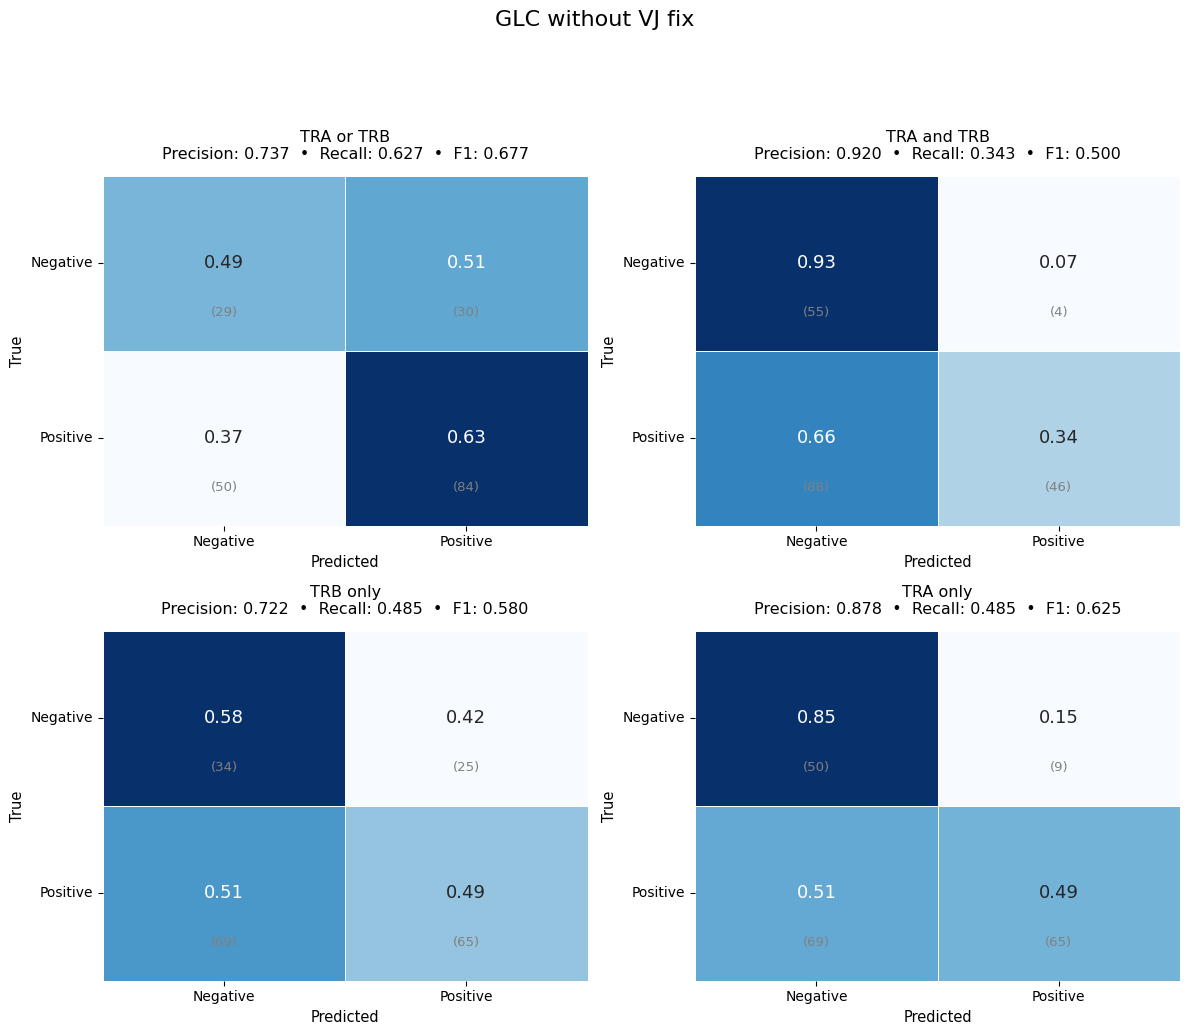

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

# Предполагаем, что у вас есть:
# tcrvdb.valid           → y_true
# tcrvdb.tra_or_trb      → y_pred 1
# и т.д.

# Вычисляем матрицы
cm1 = confusion_matrix(tcrvdb.valid, tcrvdb.tra_or_trb)
cm2 = confusion_matrix(tcrvdb.valid, tcrvdb.tra_and_trb)
cm3 = confusion_matrix(tcrvdb.valid, tcrvdb.TRB_tcrnet)
cm4 = confusion_matrix(tcrvdb.valid, tcrvdb.TRA_tcrnet)

model_names = [
    "TRA or TRB",
    "TRA and TRB",
    "TRB only",
    "TRA only"
]

cms = [cm1, cm2, cm3, cm4]
y_trues  = [tcrvdb.valid] * 4
y_preds  = [
    tcrvdb.tra_or_trb,
    tcrvdb.tra_and_trb,
    tcrvdb.TRB_tcrnet,
    tcrvdb.TRA_tcrnet
]

# ────────────────────────────────────────────────
# Основной график 2×2
# ────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("GLC without VJ fix", fontsize=16, y=1.03)

for ax, cm, y_true, y_pred, title in zip(axes.flat, cms, y_trues, y_preds, model_names):
    # Метрики (positive class = 1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, pos_label=1, average='binary', zero_division=0
    )
    
    # Заголовок с метриками
    metrics_text = f"Precision: {precision:.3f}  •  Recall: {recall:.3f}  •  F1: {f1:.3f}"
    ax.set_title(f"{title}\n{metrics_text}", fontsize=11.5, pad=12)
    
    # Нормализованная матрица (по строкам = recall по классам)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Heatmap
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar=False,
        ax=ax,
        linewidths=0.6,
        linecolor='white',
        annot_kws={"size": 13}
    )
    
    # Абсолютные значения мелким шрифтом
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = int(cm[i, j])
            ax.text(j + 0.5, i + 0.78, f"({count})",
                    ha="center", va="center",
                    color="gray", fontsize=9.5)
    
    ax.set_xlabel("Predicted", fontsize=10.5)
    ax.set_ylabel("True", fontsize=10.5)
    
    # Подписи классов (если бинарная классификация)
    class_labels = ["Negative", "Positive"]
    ax.set_xticklabels(class_labels, fontsize=10)
    ax.set_yticklabels(class_labels, fontsize=10, rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('results/GLC_without_VJ_fix.pdf')
plt.show()

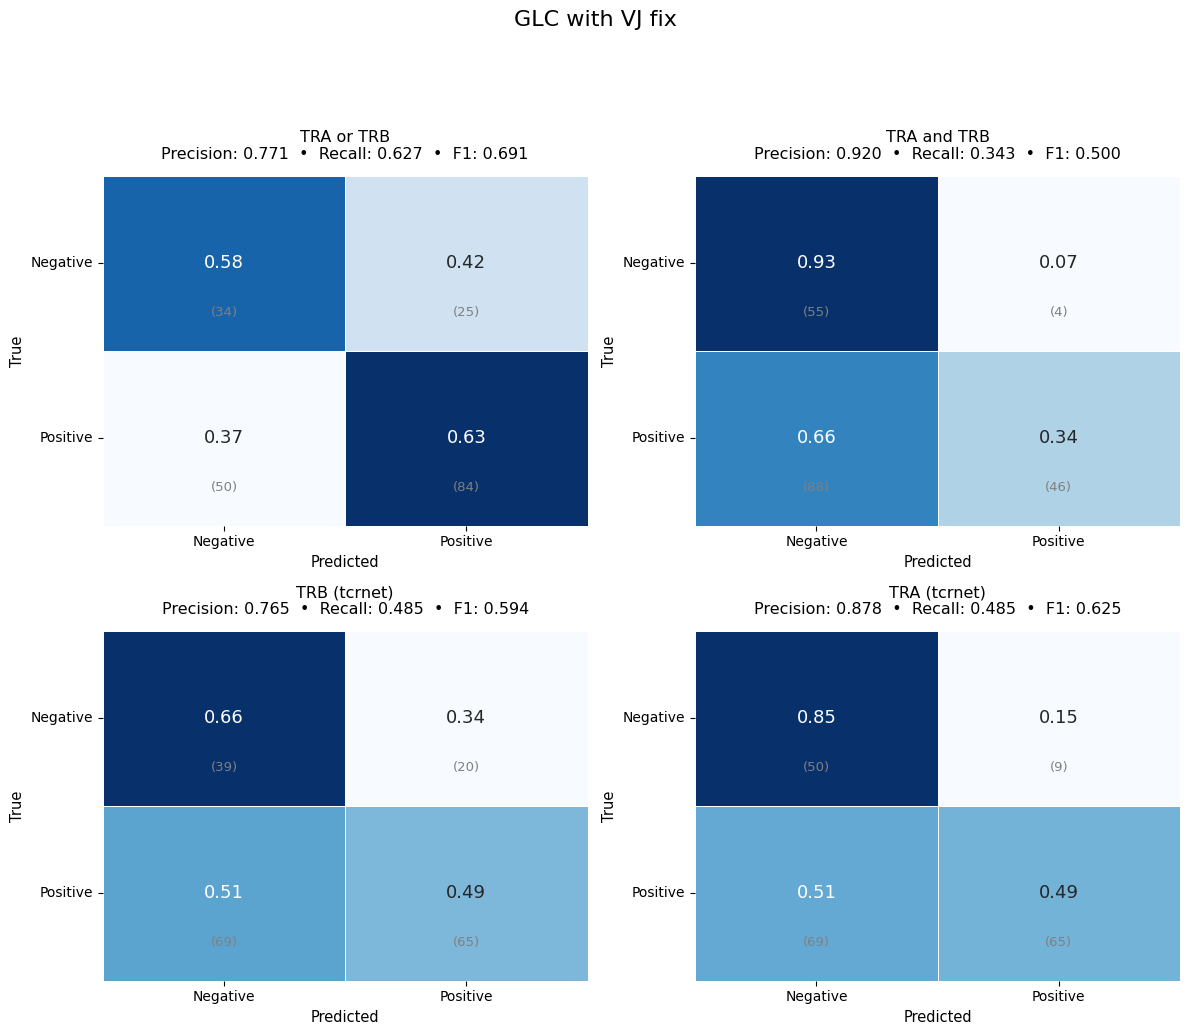

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

# Предполагаем, что у вас есть:
# tcrvdb.valid           → y_true
# tcrvdb.tra_or_trb      → y_pred 1
# и т.д.

# Вычисляем матрицы
cm1 = confusion_matrix(tcrvdb.valid, tcrvdb.tra_or_trb_vj)
cm2 = confusion_matrix(tcrvdb.valid, tcrvdb.tra_and_trb_vj)
cm3 = confusion_matrix(tcrvdb.valid, tcrvdb.TRB_tcrnet_with_seg)
cm4 = confusion_matrix(tcrvdb.valid, tcrvdb.TRA_tcrnet_with_seg)

model_names = [
    "TRA or TRB",
    "TRA and TRB",
    "TRB (tcrnet)",
    "TRA (tcrnet)"
]

cms = [cm1, cm2, cm3, cm4]
y_trues  = [tcrvdb.valid] * 4
y_preds  = [
    tcrvdb.tra_or_trb_vj,
    tcrvdb.tra_and_trb_vj,
    tcrvdb.TRB_tcrnet_with_seg,
    tcrvdb.TRA_tcrnet_with_seg
]

# ────────────────────────────────────────────────
# Основной график 2×2
# ────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("GLC with VJ fix", fontsize=16, y=1.03)

for ax, cm, y_true, y_pred, title in zip(axes.flat, cms, y_trues, y_preds, model_names):
    # Метрики (positive class = 1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, pos_label=1, average='binary', zero_division=0
    )
    
    # Заголовок с метриками
    metrics_text = f"Precision: {precision:.3f}  •  Recall: {recall:.3f}  •  F1: {f1:.3f}"
    ax.set_title(f"{title}\n{metrics_text}", fontsize=11.5, pad=12)
    
    # Нормализованная матрица (по строкам = recall по классам)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Heatmap
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar=False,
        ax=ax,
        linewidths=0.6,
        linecolor='white',
        annot_kws={"size": 13}
    )
    
    # Абсолютные значения мелким шрифтом
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = int(cm[i, j])
            ax.text(j + 0.5, i + 0.78, f"({count})",
                    ha="center", va="center",
                    color="gray", fontsize=9.5)
    
    ax.set_xlabel("Predicted", fontsize=10.5)
    ax.set_ylabel("True", fontsize=10.5)
    
    # Подписи классов (если бинарная классификация)
    class_labels = ["Negative", "Positive"]
    ax.set_xticklabels(class_labels, fontsize=10)
    ax.set_yticklabels(class_labels, fontsize=10, rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('results/GLC_with_VJ_fix.pdf')
plt.show()